In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import os
import neurokit2 as nk

In [2]:
df1 = pd.read_csv("ECGank.csv")
df2 = pd.read_csv("ECGank2.csv")
df3 = pd.read_csv("ECGcon.csv")
df4 = pd.read_csv("ECGcon.csv")

In [4]:
print(df1.describe())
print(df2.describe())
print(df3.describe())
print(df4.describe())

               Time     Channel 1    Channel 2     Channel 3
count  10001.000000  10001.000000  9988.000000  10001.000000
mean       5.000000     -0.002364     0.082583      0.000307
std        2.887184     21.659179     0.147894      0.060299
min        0.000000   -151.250000     0.005000     -0.426000
25%        2.500000     -5.160000     0.037200     -0.015000
50%        5.000000     -0.160000     0.040300      0.000000
75%        7.500000      5.160000     0.060900      0.013000
max       10.000000    151.250000     0.822800      0.425000
               Time     Channel 1    Channel 2     Channel 3
count  10000.000000  10000.000000  9982.000000  10000.000000
mean       4.999500      0.007188     0.018766      0.026042
std        2.886896      2.397819     0.001389      0.025272
min        0.000000     -4.840000     0.000600     -0.021000
25%        2.499750     -2.190000     0.018100      0.006000
50%        4.999500      0.000000     0.018800      0.020000
75%        7.499250     

In [5]:
dfs_dict = {
    'Ank atrial 1': df1,
    'Ank atrial 2': df2,
    'Control atrial 1': df3,
    'Control atrial 2': df4
}


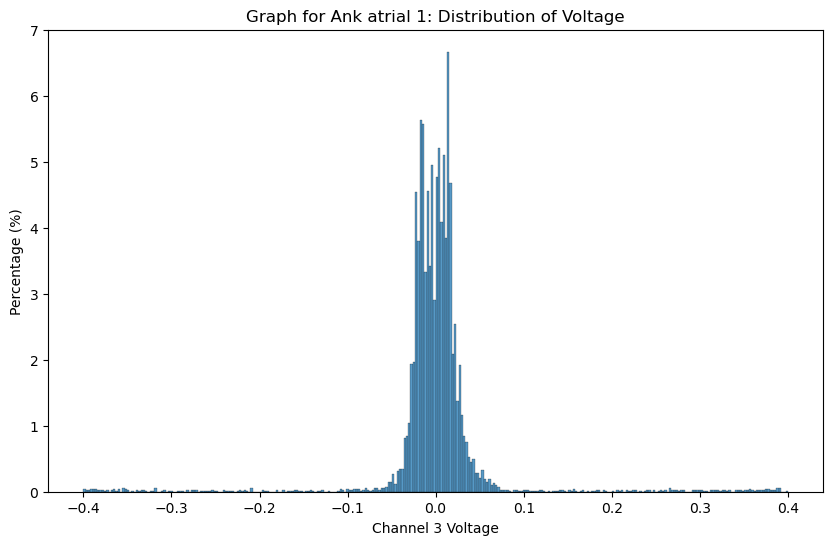

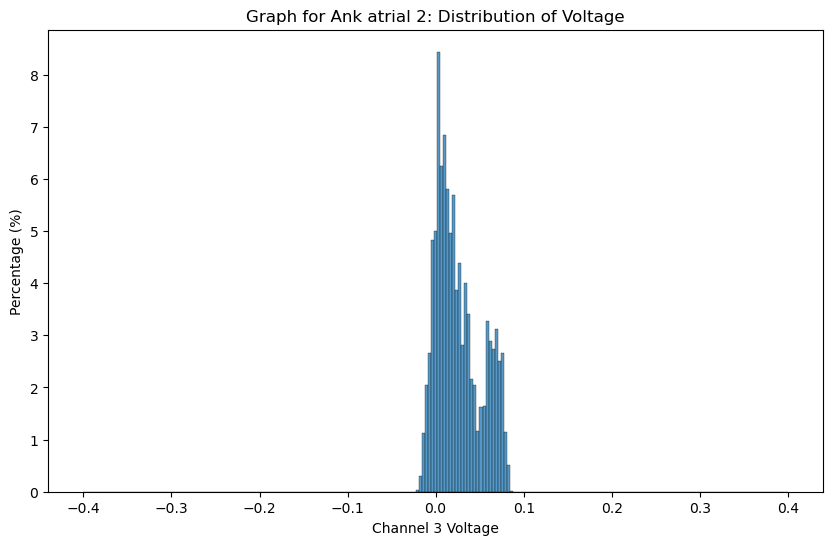

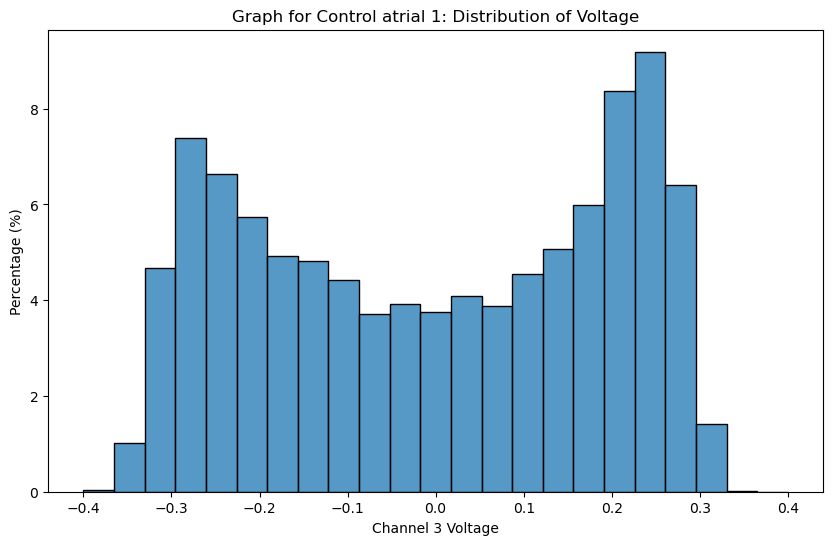

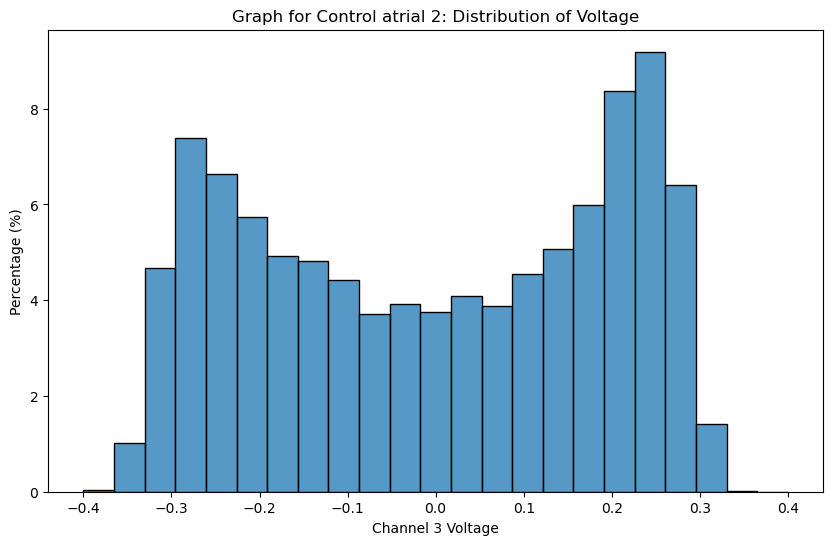

In [9]:
for name, chunk_df in dfs_dict.items():
    plt.figure(figsize=(10, 6))
    sns.histplot(data=chunk_df, x='Channel 3', stat='percent', binrange = (-0.4 , 0.4))
    plt.title(f"Graph for {name}: Distribution of Voltage")
    plt.xlabel("Channel 3 Voltage")
    plt.ylabel("Percentage (%)")
    plt.show()

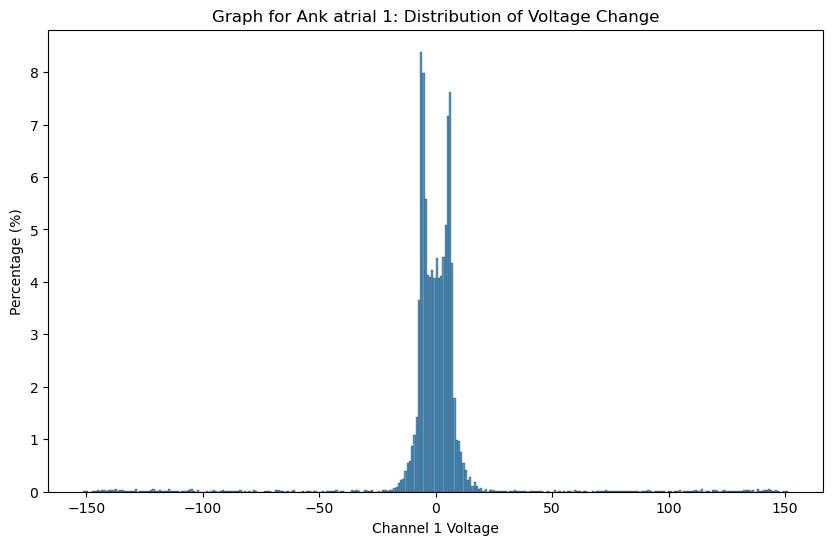

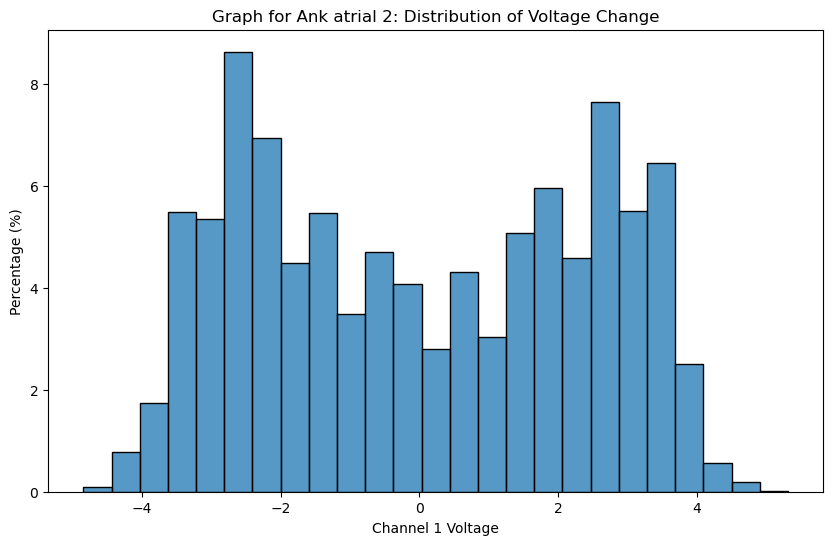

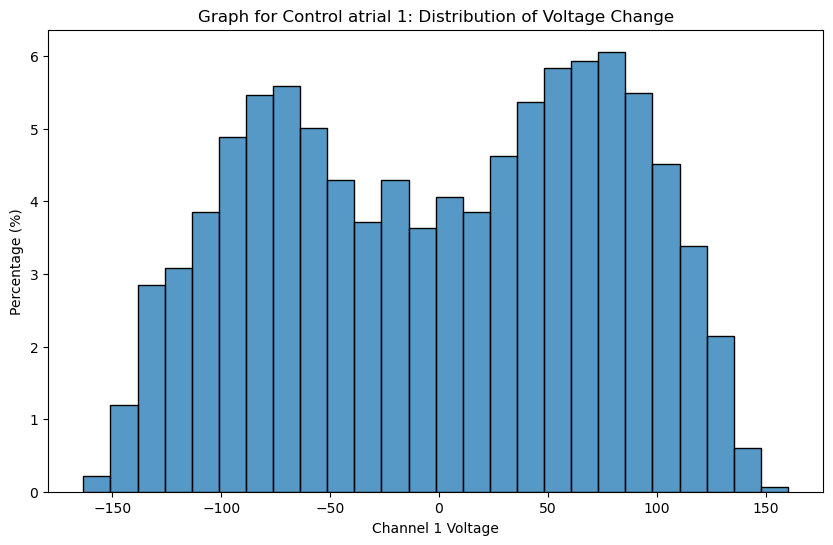

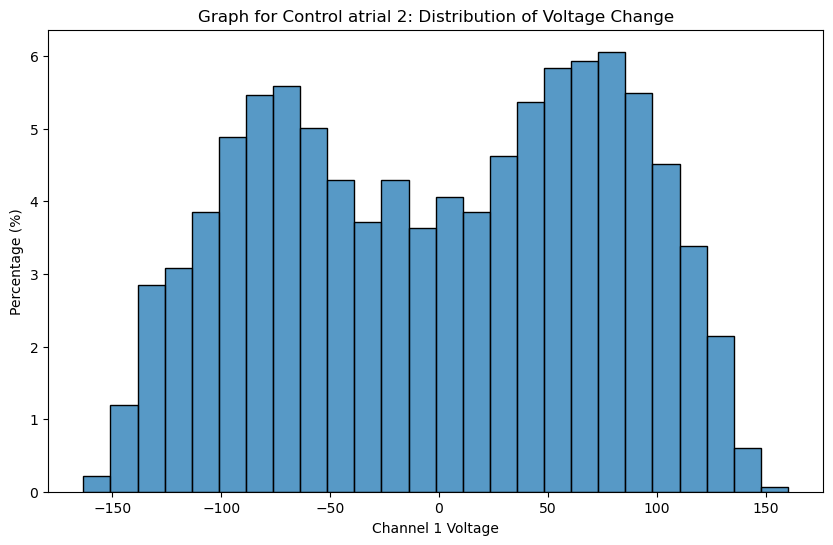

In [10]:
for name, chunk_df in dfs_dict.items():
    plt.figure(figsize=(10, 6))
    sns.histplot(data=chunk_df, x='Channel 1', stat='percent')
    plt.title(f"Graph for {name}: Distribution of Voltage Change")
    plt.xlabel("Channel 1 Voltage")
    plt.ylabel("Percentage (%)")
    plt.show()

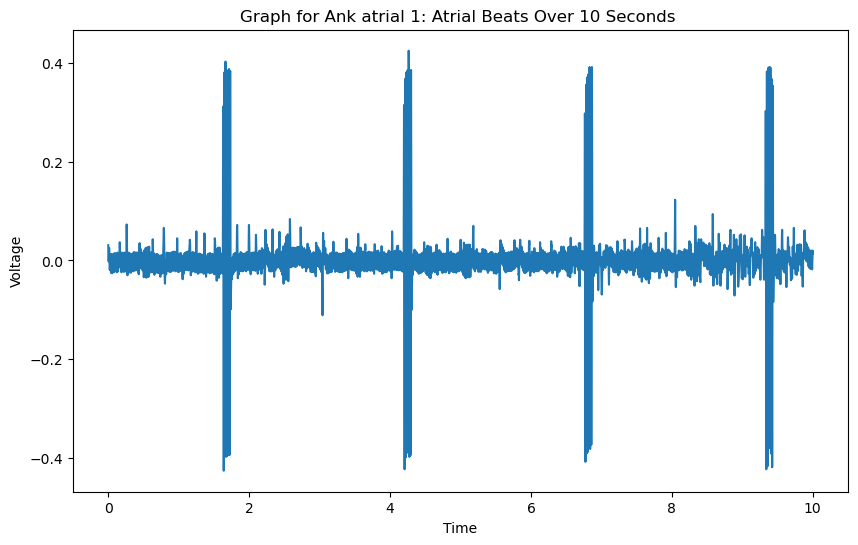

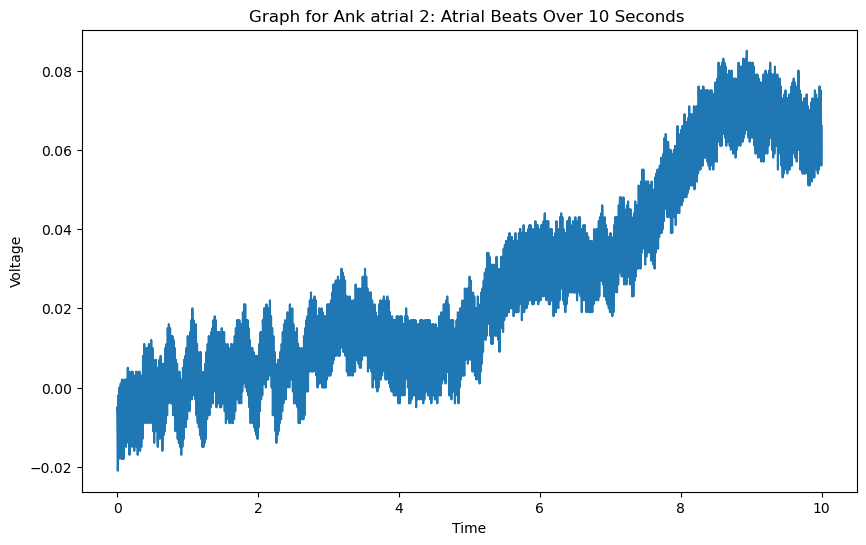

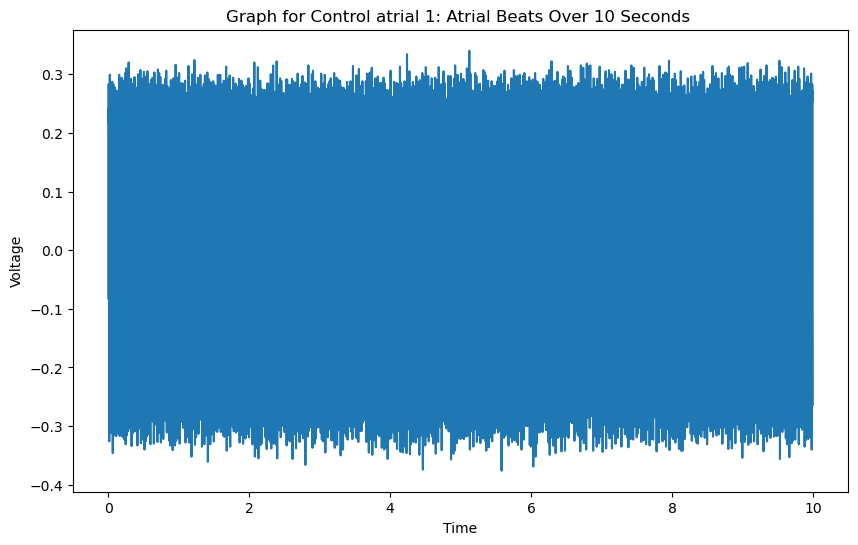

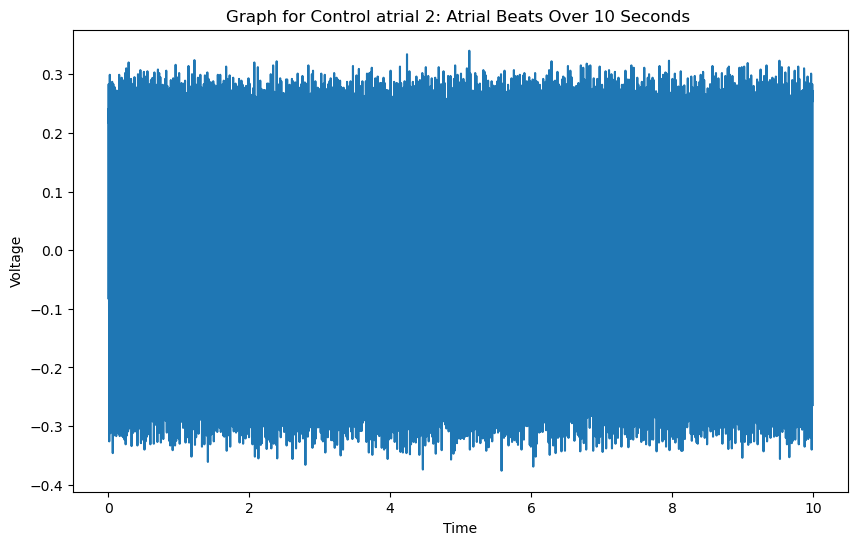

In [13]:
for name, chunk_df in dfs_dict.items():
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=chunk_df, x = "Time" , y = "Channel 3")
    plt.title(f"Graph for {name}: Atrial Beats Over 10 Seconds ")
    plt.xlabel("Time")  # Replace with actual column name if necessary
    plt.ylabel("Voltage")
    plt.show()

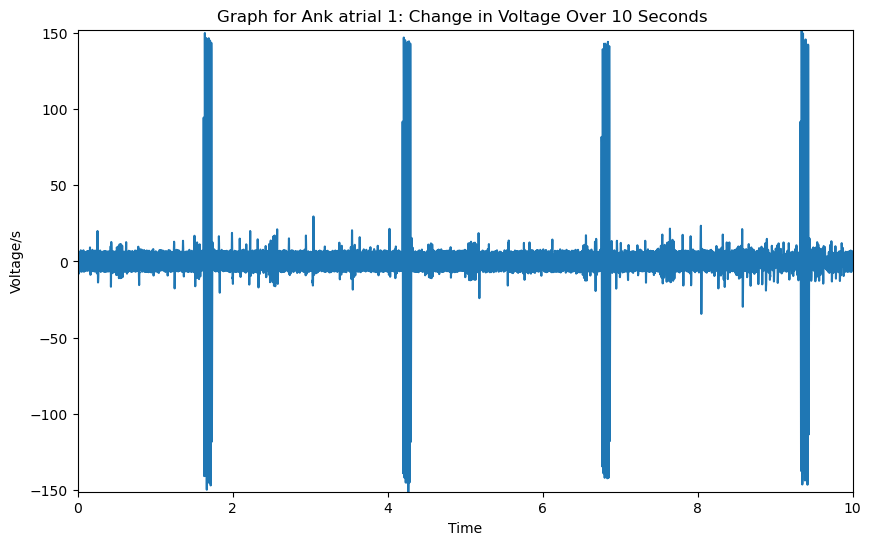

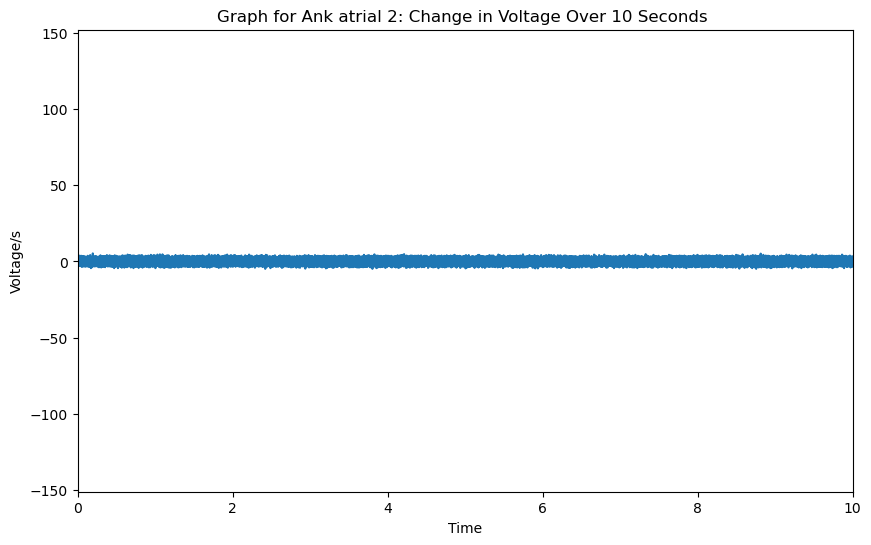

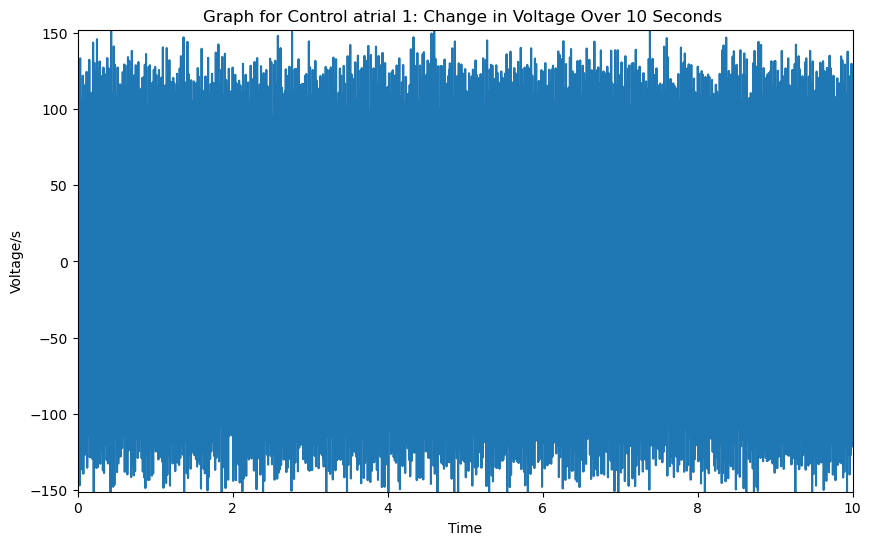

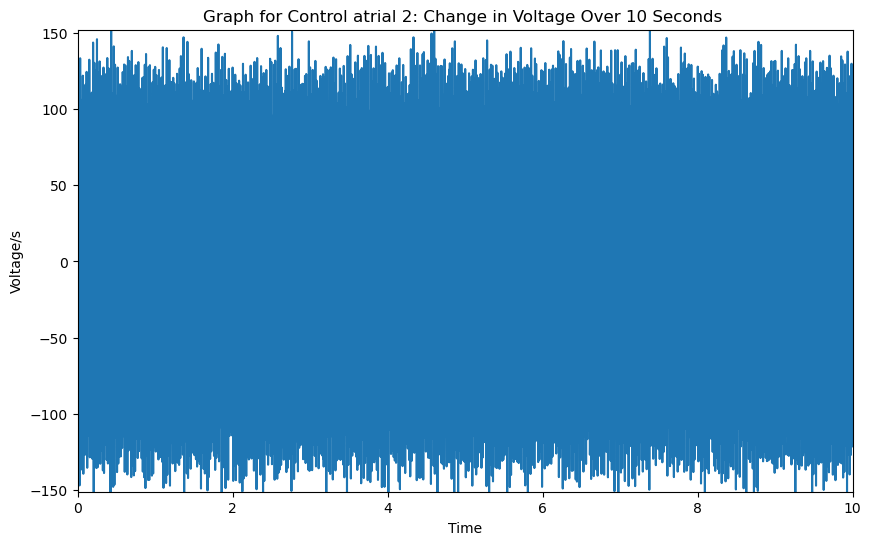

In [19]:
for name, chunk_df in dfs_dict.items():
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=chunk_df, x = "Time" , y = "Channel 1")
    plt.title(f"Graph for {name}: Change in Voltage Over 10 Seconds ")
    plt.xlabel("Time")  # Replace with actual column name if necessary
    plt.ylabel("Voltage/s")
    # Set x-axis and y-axis limits
    plt.xlim(0, 10)  # For example, limit x-axis from 0 to 100
    plt.ylim(-151,152)   # For example, limit y-axis from 0 to 10
    plt.show()

In [15]:
def create_normalized_column(df):
    # You can modify this calculation based on your needs
    # For example, if you want to normalize based on a max value in some column:
    df['Normalized V/s (%)'] = (df['Channel 1'] / df['Channel 1'].max()) * 100  # Adjust column name as needed
    return df

# Function to calculate Total_AoTDC for each DataFrame
def calculate_total_aotdc(df):
    # Create the 'Normalized V/s (%)' column if it doesn't exist
    df = create_normalized_column(df)

    # Perform the calculations based on the 'Normalized V/s (%)' column
    Number_of_samples_abovec = df['Normalized V/s (%)'] > 25
    Number_of_samples_belowc = df['Normalized V/s (%)'] < -25
    above_belowc = Number_of_samples_belowc + Number_of_samples_abovec
    above_below_sumc = above_belowc.sum()
    timerecorded = df['Time'].count()  # Assuming 'Time' column exists

    # Calculate Total_AoTDC
    Total_AoTDC = above_below_sumc / timerecorded
    return Total_AoTDC

# List to store the results (DataFrame name and Total_AoTDC)
results = []

# Iterate through the dictionary to calculate Total_AoTDC for each DataFrame
for name, df in dfs_dict.items():
    total_aotdc = calculate_total_aotdc(df)
    results.append([name, total_aotdc])

# Create a new DataFrame with the results
df_result = pd.DataFrame(results, columns=['Cell Type', 'Total Time above 25%'])

# Display the result
print(df_result)


          Cell Type  Total Time above 25%
0      Ank atrial 1              0.036096
1      Ank atrial 2              0.742000
2  Control atrial 1              0.736300
3  Control atrial 2              0.736300


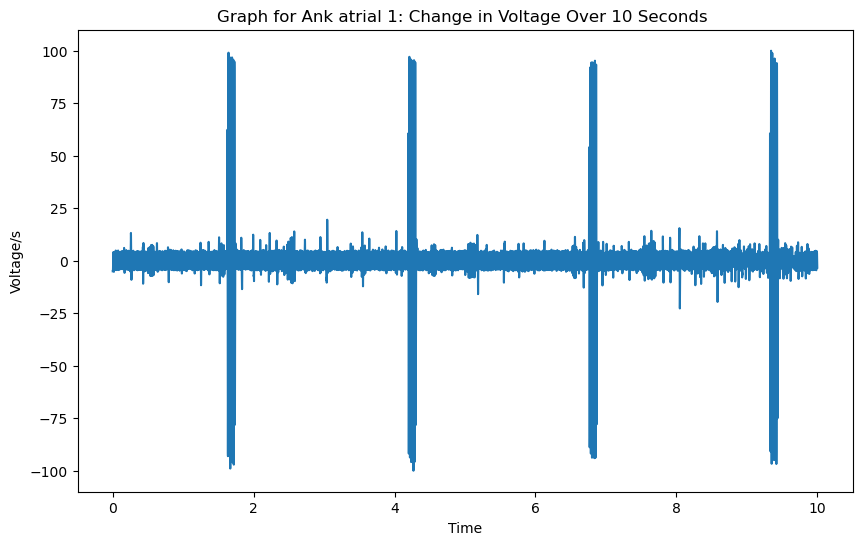

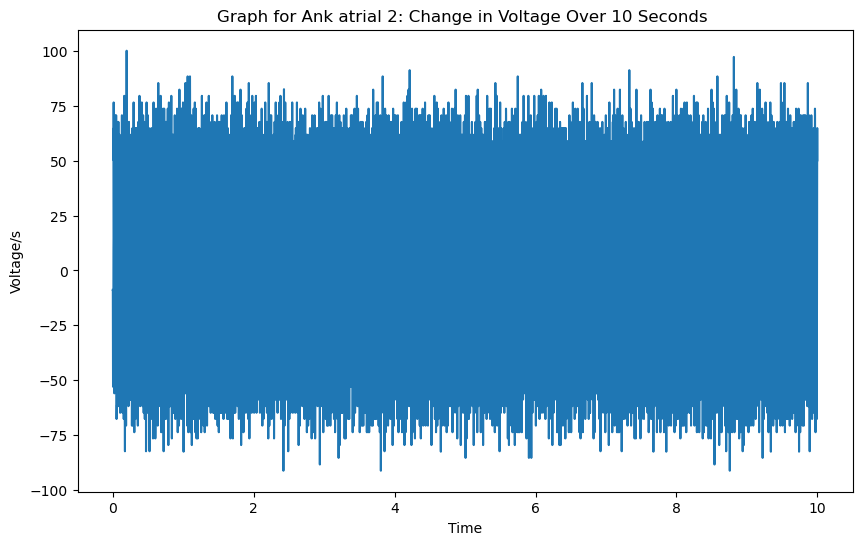

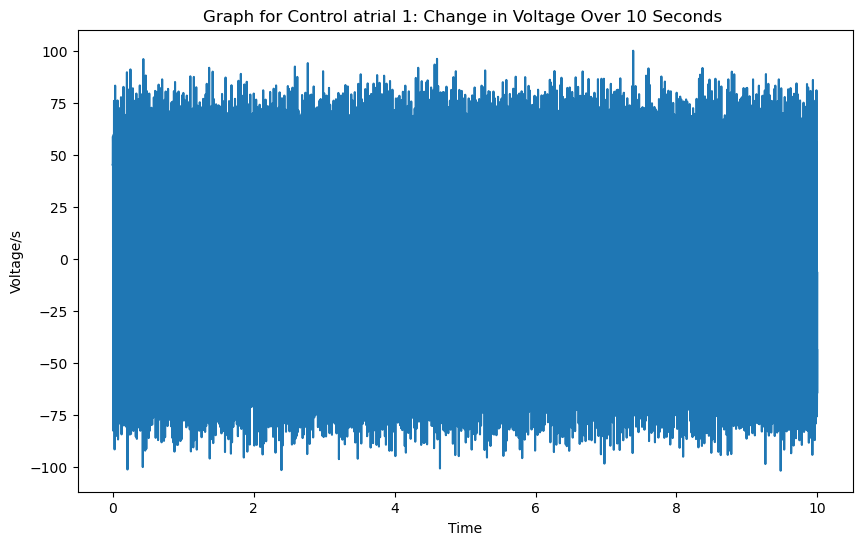

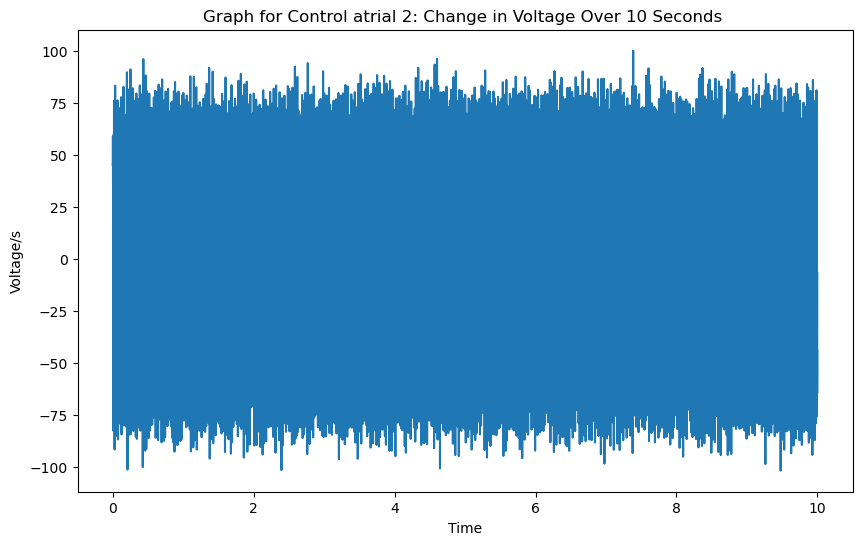

In [18]:
for name, chunk_df in dfs_dict.items():
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=chunk_df, x = "Time" , y = "Normalized V/s (%)")
    plt.title(f"Graph for {name}: Change in Voltage Over 10 Seconds ")
    plt.xlabel("Time")  # Replace with actual column name if necessary
    plt.ylabel("Voltage/s")
    plt.show()

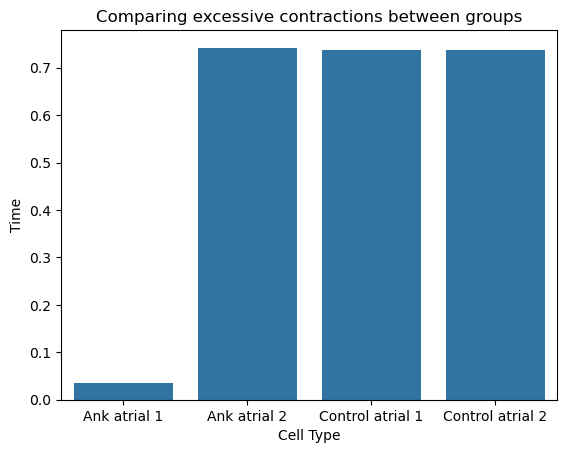

In [17]:
sns.barplot(data=df_result, x = "Cell Type" , y = "Total Time above 25%")

# Customize the plot
plt.xlabel('Cell Type')
plt.ylabel('Time')
plt.title('Comparing excessive contractions between groups')
plt.show()